<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/MarkovChainRule5thOct2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Markov Chain**
It is a system that moves between state over the time. The key property of Markov chain is:
* The probabilty of the next state depends only on the current state, not on the full pass state

###**For Example**
In a canteen there are three dishes - A, B ,C. What to get served tomorrow will be depending on today's dish
* State : A,B,C
* Transistion: Moving from today's dish(current state) to the tommorow dish(Next state)
* Transition probabitly: p(A|B) -> Probabilty that tomorrow is A given that today is B

###**Convections to use**
There are two types of convections
* **Row-stochastic Convection** -> In matrix row wise sum = 1
* **column-stochastic Convection** -> In matrix column wise sum = 1

**We are going to use Column-stochastic convection**
* Matrix (p) Columns = Current state, Rows = Next state
* Each columns sums to 1 (Probabilities of where you go from the current)
* State vector (pi_t) = A 3x1 column vector(contains probabiliteis for state A,B,C at the time t)
* `update Rule: pi_t+1 = P x pi_t`

**Matrix P**

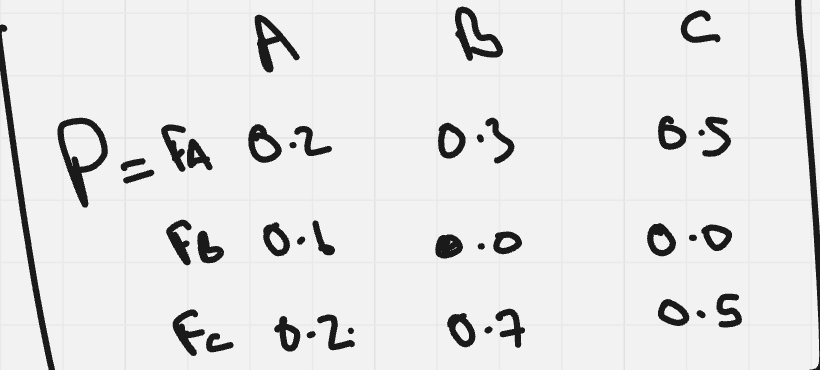

**Current state Vector**

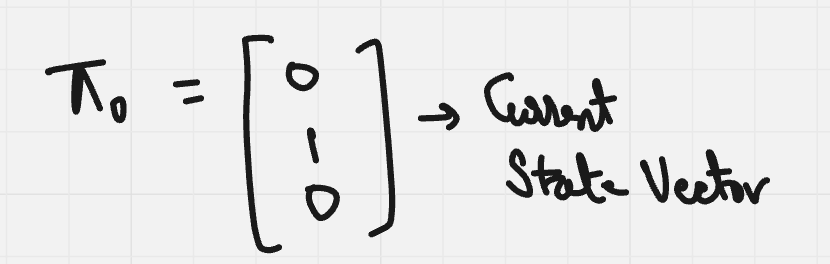

**Updated State Vector**

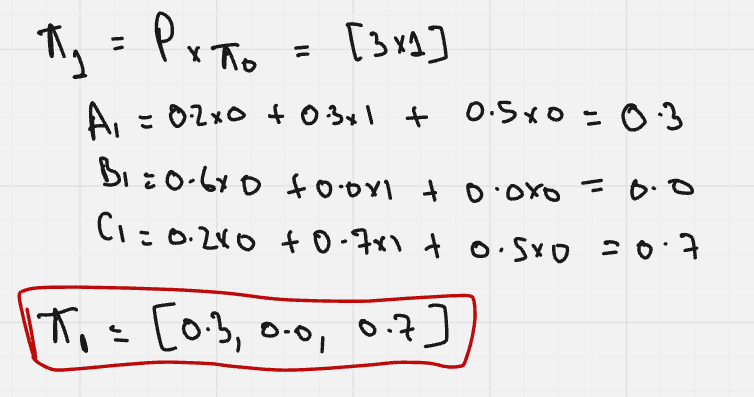

30% chances are that it would be dish A next day and 70% chances for C

---

Let's Check for the next state

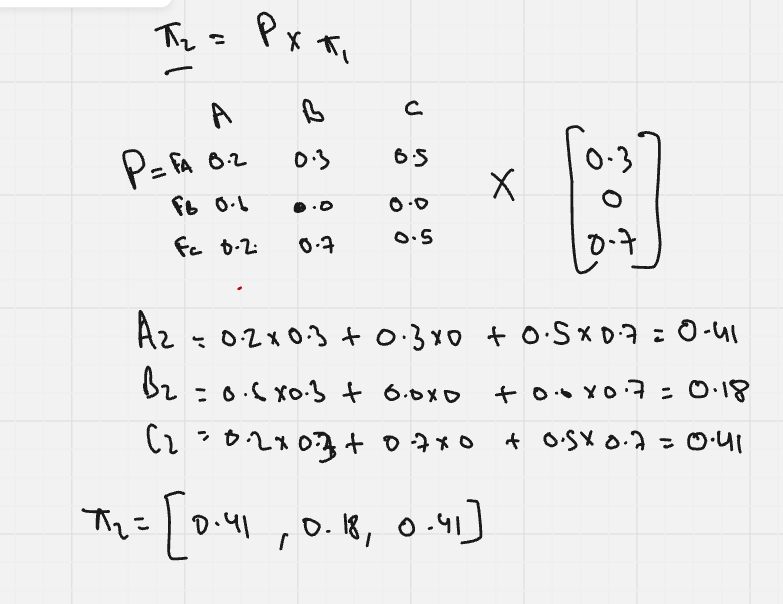

###**n-step transition (power of the matrix)**
The matrix power (p^n) collects n-step transition probabilites (next = i| current = j)

`p^n[i,j] = p(state i after n steps | starts in state j)`

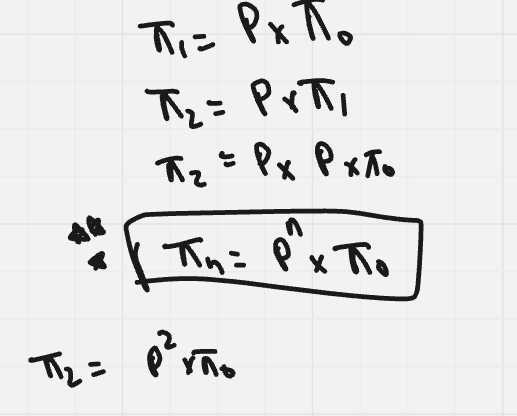

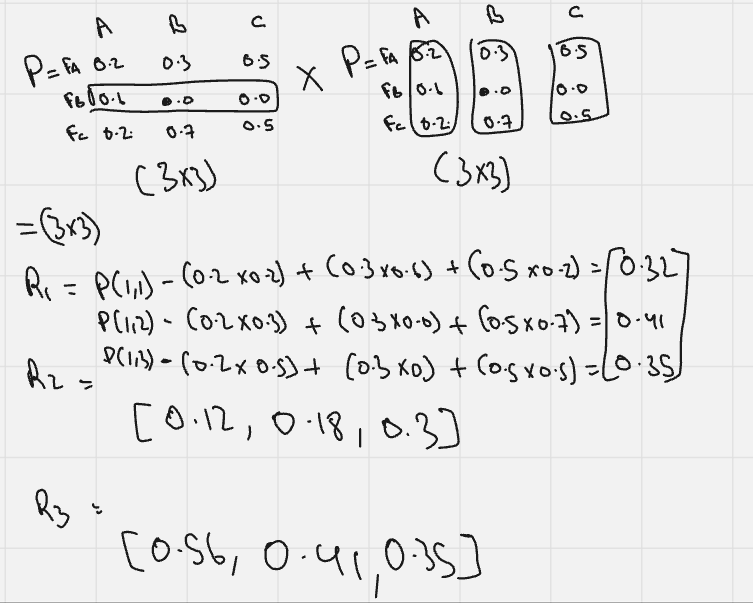

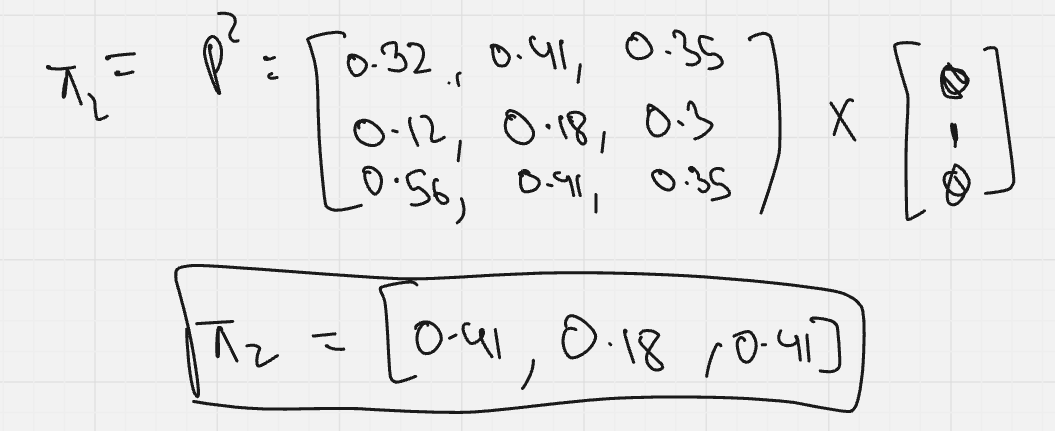

If we observe, it is same as the previous one we got

---
Let's Implement it using python

In [ ]:
import numpy as np
P = np.array([
    [0.2,0.3,0.5], # Future A
    [0.6,0.0,0.0], # Future B
    [0.2,0.7,0.5]  # Future C
])

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
pi0 = np.array([0,1,0])

In [ ]:
pi1 = P @ pi0
pi1

array([0.3, 0. , 0.7])

**Let's Implement for the second method**

In [ ]:
n = 2
pin = np.linalg.matrix_power(P,n) @ pi0
pin

array([0.41, 0.18, 0.41])

###**Stationary Distribution (Equilibrium)**
In longer run, we get stationary distribution (pi*) that is a probabilty vector does not change under the updates

`P x pi* = pi*`

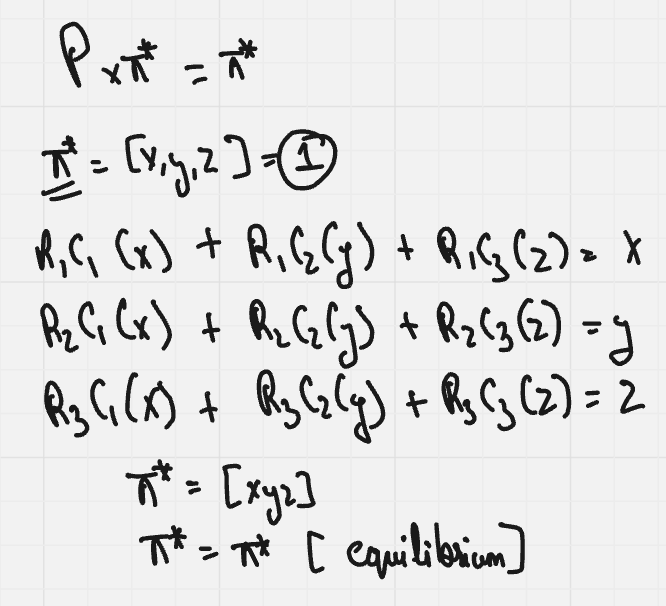

Once we equate all the equations -> x,y,z --> Normalize it as X+Y+Z = 1 ---> Equilibrium

**Let's See the equilibrium using python**

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
eigvals , eigvec = np.linalg.eig(P)

In [ ]:
eigvals

array([ 1.  +0.j       , -0.15+0.3122499j, -0.15-0.3122499j])

In [ ]:
eigvec

array([[-0.58746336+0.j        , -0.16984156+0.35355339j,
        -0.16984156-0.35355339j],
       [-0.35247801+0.j        ,  0.67936622+0.j        ,
         0.67936622-0.j        ],
       [-0.72845456+0.j        , -0.50952467-0.35355339j,
        -0.50952467+0.35355339j]])

In [ ]:
oneIndex = np.argmin(np.abs(eigvals-1))
oneIndex

np.int64(0)

In [ ]:
type(-0.58746336+0.j)

complex

**Let's Extract the vectors related to eigval[0]**

In [ ]:
stationaryVector = np.real(eigvec[:,oneIndex])

In [ ]:
stationaryVector

array([-0.58746336, -0.35247801, -0.72845456])

In [ ]:
sum(stationaryVector) # We are not getting 1 as a sum so let's normalize it

np.float64(-1.6683959370487886)

In [ ]:
stationaryNormalized = stationaryVector/stationaryVector.sum()

In [ ]:
stationaryNormalized # ----> Equilibrium value (pi*)
# [0.352321 0.21119  0.436489]

array([0.35211268, 0.21126761, 0.43661972])

**Let's use loop approach to find p***

In [ ]:

P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
states = ['A','B','C']

In [ ]:
def markovChain(P,start = 0, step = 100000):
  current = start
  counts = np.zeros(P.shape[0]) # We are creating a counter for how many times each state is visited

  for i in range(step):
    current = np.random.choice(len(states),p=P[:,current]) # here we are picking the next state randomly, using the probabilites in column current of P
    counts[current] +=1
  return counts/step

In [ ]:
x = markovChain(P,start=0 , step = 1000000)
print(x)

[0.352321 0.21119  0.436489]


##**pymarkovchain**

In [ ]:
pip install pymarkovchain

  Preparing metadata (setup.py) ... done
  Created wheel for pymarkovchain: filename=PyMarkovChain-1.8-py3-none-any.whl size=4322 sha256=52f4a68fa21a419289024b4212d1fa5e3d61d581a076b016ff604ca3f8f8bfad
  Stored in directory: /root/.cache/pip/wheels/0d/2b/37/27274de277251f7027e458b3789215b481ff8118d17a153199
Successfully built pymarkovchain


In [ ]:
from pymarkovchain import MarkovChain

In [ ]:
P

array([[0.2, 0.3, 0.5],
       [0.6, 0. , 0. ],
       [0.2, 0.7, 0.5]])

In [ ]:
states

['A', 'B', 'C']

In [ ]:
def training_sequence(P,start = 0, step = 1000):
  current = start
  sequence = [states[current]]
  for i in range(step):
    current = np.random.choice(len(states),p=P[:,current])
    sequence.append(states[current])

  return " ".join(sequence)


In [ ]:
trainText = training_sequence(P,start = 0, step = 10000)

In [ ]:
trainText

'A B A B A A A C C C A B A B C C A B C A C A B C C A C A C A B C A A C A A A B C C C C C A B C C A C A A B C A C A B A B C A C A C A B C C A A B A B C C C C C C C C A B A B C C A B C A B C C C A B C C C A A A B C A B C C C A C C C C A A B C A B C C A B C C A B C A C C A A B C A B A A B A B A B C A B C A B C C A B A B A B A B C A B A C C A B C A C A B A C C A B C A B C A A B A A C A B C C C C A A A B C A B A C C A A B C A B C A A C A B C C A B C A C A B C A B C A B C A B C C C A B A A C A B C C C C C A B C C A C A A A C C C C C A C A B A B C A B C C C A B C C C A B A A A A A A B C C A A B C A A C C C A A B C C C C A B C C C C C C C A B C A C A C A B C C C A A B C C A B C A C A C C A B C C A B C A B A B C C C C A A B C A B C C C A B A B C C C A C A C C C C A A C C C C C C A A B C A B C A B C C A A A A B A B C A A B C A B C C A A B A B C A B C A A B A A B C A A A B C A B A B C A B C A B A B C C C C A B C C C C C C A B C C A B A B C C A B C C C C A B C A C C A B A C A C A B C C A B C A B C

**let's implement markov chain**

In [ ]:
mc = MarkovChain()
mc.generateDatabase(trainText)

In [ ]:
generateString = mc.generateStringWithSeed('A')

generateString

'A B C C A B C C C C A B C C A C A B A B C C C A B A B A B A C A B A B C A A B C A B C A B A B A B C C A B C C C A B C C A A B C A B C C C C A B A C A B C A B C C C C C A B C C C C C C A B C A B C A A A B A B A A B C A B C C A C A B C C A B C A B C A B C C C A B A C A A B A A B A B A B A B C C C A C C C A A A C C A B C C C A B C C A B C A B C C C C C C C C C C A B C A B C A C A A B C A A C C C C A C A C A B A A B A B A B C C C A C C A B C C C C C C C A A B C A A C C A A A A B C C A A B A B A B A B C A B C A B A B C C A B C C A B C C A B C C A B C C A B C A C A B C A B C A B A B A C A B A C C A B A B C A C C A A C A B C C C C C C C C A C C A B C C A B A B C A A A B C C A C C A C A B A C A A B C A B C C A C C A A B C A A C A B C C C C C C C C A C A B A B A B A C A B A B C C A B A B A B C C C A B C C A C C C C A B A C C A B C A C C A B C C A B C C A A B C A C A C C A B C C C C A B C C C C C A B A B C C C A B C C C A A A B A B C C A B C A B A B C C A B C A A C A B A B C C A B A B A A B C A

**Let's take some real example**

In [ ]:
training_text = """
Harry Potter is a series of seven fantasy novels written by British author J. K. Rowling. The novels chronicle the lives of a young wizard, Harry Potter, and his friends, Ron Weasley and Hermione Granger, all of whom are students at Hogwarts School of Witchcraft and Wizardry."""

mc1 = MarkovChain()
mc1.generateDatabase(training_text)

In [ ]:
generatedText = mc1.generateString()

In [ ]:
generatedText

'The novels chronicle the lives of a young wizard, Harry Potter, and his friends, Ron Weasley and Hermione Granger, all of whom are students at Hogwarts School of Witchcraft and Wizardry'

##**Markovify (Other Library)**

In [ ]:
pip install markovify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import markovify as mk

**Load the data**

**Dataset link** - https://drive.google.com/file/d/1nuDVhyJ_HM8FyesBdk1YUPEVraIU5t7S/view?usp=sharing

In [ ]:
df = pd.read_json('/content/arxivData.json')

In [ ]:
df.head()

,author,day,id,link,month,summary,tag,title,year
0,"[{'name': 'Ahmed Osman'}, {'name': 'Wojciech S...",1,1802.00209v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",2,We propose an architecture for VQA which utili...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",Dual Recurrent Attention Units for Visual Ques...,2018
1,"[{'name': 'Ji Young Lee'}, {'name': 'Franck De...",12,1603.03827v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",3,Recent approaches based on artificial neural n...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Sequential Short-Text Classification with Recu...,2016
2,"[{'name': 'Iulian Vlad Serban'}, {'name': 'Tim...",2,1606.00776v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",6,We introduce the multiresolution recurrent neu...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Multiresolution Recurrent Neural Networks: An ...,2016
3,"[{'name': 'Sebastian Ruder'}, {'name': 'Joachi...",23,1705.08142v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",5,Multi-task learning is motivated by the observ...,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...",Learning what to share between loosely related...,2017
4,"[{'name': 'Iulian V. Serban'}, {'name': 'Chinn...",7,1709.02349v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",9,We present MILABOT: a deep reinforcement learn...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",A Deep Reinforcement Learning Chatbot,2017


In [ ]:
df['TextOnly'] = df['title'] + ': ' + df['summary']

In [ ]:
df['TextOnly'].iloc[0]

'Dual Recurrent Attention Units for Visual Question Answering: We propose an architecture for VQA which utilizes recurrent layers to\ngenerate visual and textual attention. The memory characteristic of the\nproposed recurrent attention units offers a rich joint embedding of visual and\ntextual features and enables the model to reason relations between several\nparts of the image and question. Our single model outperforms the first place\nwinner on the VQA 1.0 dataset, performs within margin to the current\nstate-of-the-art ensemble model. We also experiment with replacing attention\nmechanisms in other state-of-the-art models with our implementation and show\nincreased accuracy. In both cases, our recurrent attention mechanism improves\nperformance in tasks requiring sequential or relational reasoning on the VQA\ndataset.'

In [ ]:
df['TextOnly'] = df['TextOnly'].map(lambda x:x.replace('\n',' '))

In [ ]:
df['TextOnly'].iloc[0]

'Dual Recurrent Attention Units for Visual Question Answering: We propose an architecture for VQA which utilizes recurrent layers to generate visual and textual attention. The memory characteristic of the proposed recurrent attention units offers a rich joint embedding of visual and textual features and enables the model to reason relations between several parts of the image and question. Our single model outperforms the first place winner on the VQA 1.0 dataset, performs within margin to the current state-of-the-art ensemble model. We also experiment with replacing attention mechanisms in other state-of-the-art models with our implementation and show increased accuracy. In both cases, our recurrent attention mechanism improves performance in tasks requiring sequential or relational reasoning on the VQA dataset.'

**Build our markov chain**

In [ ]:
textModel = mk.NewlineText(df['TextOnly'], state_size = 2)

In [ ]:
textModel.make_sentence()

'Deep Image Category Discovery using a neural system by drawing additional supervision from the mixed signals, letting collections of text processing can be compiled to a limited amount of explosively increasing science and economics. The nonlinear transformation from the previous approaches, which constrain language designers to specific ego-motions is a very small performance drop after pruning is shown.'

In [ ]:
# print(textModel.make_short_sentence(max_chars = 40))

None


In [ ]:
for i in range(10):
  print(textModel.make_sentence())
  print('==========================')

Deep Learning techniques. The outcome of diverse classes compared with some widely used visual features.
Verbal chunk extraction in multiple different measures of the conflict repartition enlightened by the application of clustering on real-world datasets. The experimental results demonstrating its encouraging results show the ability to recall the corresponding epitomes. We then propose a novel approach for the incorporation of morphemes annotated with pixel-accurate ground truth, and then present extensive empirical study where the reward of each of these symmetric matrices -- an important role in taking the form of visual data. Solving this problem and compare it with previous results on both the scene for suggesting potential actions, eliminating obviously inferior plans, identifying important tradeoffs, and explaining probabilistic models. The proposed methodology on simulated data that provide significant speedup versus traditional convolution network computed with cluster specif

In [ ]:
textModel3 = mk.NewlineText(df['TextOnly'], state_size = 3)
textModel4 = mk.NewlineText(df['TextOnly'], state_size = 4)

In [ ]:
for i in range(10):
  print(textModel3.make_sentence())
  print('==========================')

Stereotypical Reasoning: Logical Properties: Stereotypical reasoning assumes that the brain of any given language, screen, and dynamic reordering table of the symbols is arbitrary. The aim of SATIS is to provide to the research community.
A Dataset for Improved RGBD-based Object Detection and Segmentation: We study the entropy of types with the help of implicit information about object importance conveyed by the list of tasks that can be potentially used for subsequent big data processing: 3D scene reconstruction and other big data applications.
Fast Information-theoretic Bayesian Optimisation: Information-theoretic Bayesian optimisation techniques have demonstrated state-of-the-art performance in both single- and multi-view learning scenarios.
A Clearer Picture of Blind Deconvolution: Blind deconvolution consists of recovering a color image of any size is input for processing. The algorithm we demonstrate is the first result showing that it learned useful localization and navigation c

In [ ]:
for i in range(10):
  print(textModel4.make_sentence())
  print('==========================')

None
None
Deep Functional Maps: Structured Prediction for Dense Shape Correspondence: We introduce a new approach of PSNR-B called modified PSNR-B. it gives even better results compared to traditional methods.
None
None
None
None
None
None
None


The number of sequence were too long to get trained